In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("heart_disease_dataset.csv")

print("Dataset head:")
print(df.head())

print("\nDataset shape:", df.shape)

Dataset head:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   67    1   2       111   536    0        2       88      0      1.3      3   
1   57    1   3       109   107    0        2      119      0      5.4      2   
2   43    1   4       171   508    0        1      113      0      3.7      3   
3   71    0   4        90   523    0        2      152      0      4.7      2   
4   36    1   2       119   131    0        2      128      0      5.9      3   

   ca  thal  smoking  diabetes   bmi  heart_disease  
0   2     3        1         0  23.4              1  
1   0     3        0         1  35.4              0  
2   0     7        1         1  29.9              0  
3   1     3        1         0  15.2              1  
4   1     3        1         0  16.7              1  

Dataset shape: (3069, 17)


In [3]:
print("Missing values per column:\n")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

Missing values per column:

age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalach          0
exang            0
oldpeak          0
slope            0
ca               0
thal             0
smoking          0
diabetes         0
bmi              0
heart_disease    0
dtype: int64

Duplicate rows: 0


In [4]:
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical Columns:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nDataset AFTER encoding:")
print(df_encoded.head())

Categorical Columns: Index([], dtype='object')

Dataset AFTER encoding:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   67    1   2       111   536    0        2       88      0      1.3      3   
1   57    1   3       109   107    0        2      119      0      5.4      2   
2   43    1   4       171   508    0        1      113      0      3.7      3   
3   71    0   4        90   523    0        2      152      0      4.7      2   
4   36    1   2       119   131    0        2      128      0      5.9      3   

   ca  thal  smoking  diabetes   bmi  heart_disease  
0   2     3        1         0  23.4              1  
1   0     3        0         1  35.4              0  
2   0     7        1         1  29.9              0  
3   1     3        1         0  15.2              1  
4   1     3        1         0  16.7              1  


In [6]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'smoking', 'diabetes', 'bmi',
       'heart_disease'],
      dtype='object')


In [10]:
target_col = df_encoded.columns[-1]  # assumes last column is target
print("Target column is:", target_col)

X = df_encoded.drop(target_col, axis=1)
Y = df_encoded[target_col]

Target column is: heart_disease


In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Linear Regression Accuracy: 0.6514657980456026
             precision    recall  f1-score   support

          0       0.67      0.82      0.74       369
          1       0.59      0.40      0.48       245

avg / total       0.64      0.65      0.64       614



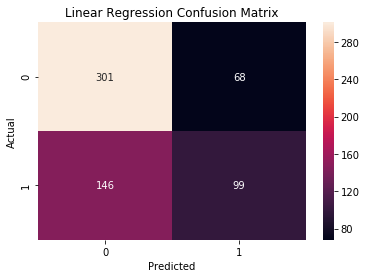

In [12]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, Y_train)

lr_pred = lr.predict(X_test)
lr_pred_class = [1 if x >= 0.5 else 0 for x in lr_pred]

print("Linear Regression Accuracy:", accuracy_score(Y_test, lr_pred_class))
print(classification_report(Y_test, lr_pred_class))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_test, lr_pred_class), annot=True, fmt="d")
plt.title("Linear Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree Accuracy: 0.5944625407166124
             precision    recall  f1-score   support

          0       0.66      0.66      0.66       369
          1       0.49      0.49      0.49       245

avg / total       0.59      0.59      0.59       614



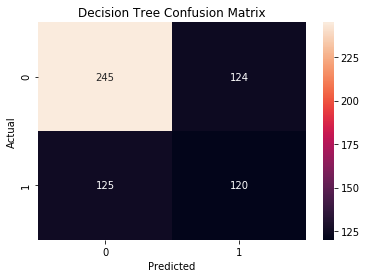

In [16]:
# decision tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, Y_train)
dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(Y_test, dt_pred))
print(classification_report(Y_test, dt_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_test, dt_pred), annot=True, fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest Accuracy: 0.6205211726384365
             precision    recall  f1-score   support

          0       0.64      0.82      0.72       369
          1       0.54      0.31      0.40       245

avg / total       0.60      0.62      0.59       614



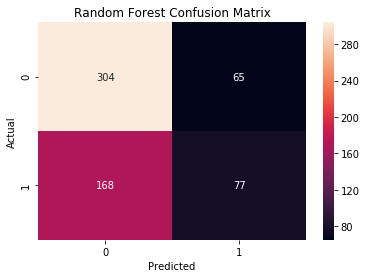

In [23]:
# Random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(Y_test, rf_pred))
print(classification_report(Y_test, rf_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_test, rf_pred), annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

KNN Accuracy: 0.5732899022801303
             precision    recall  f1-score   support

          0       0.62      0.74      0.67       369
          1       0.45      0.33      0.38       245

avg / total       0.55      0.57      0.56       614



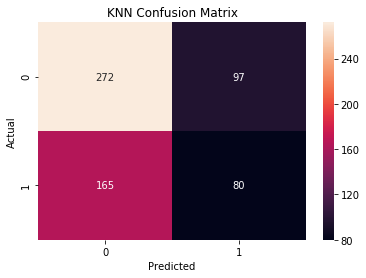

In [24]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)
knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(Y_test, knn_pred))
print(classification_report(Y_test, knn_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_test, knn_pred), annot=True, fmt="d")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

SVM Accuracy: 0.6237785016286646
             precision    recall  f1-score   support

          0       0.64      0.84      0.73       369
          1       0.55      0.30      0.39       245

avg / total       0.61      0.62      0.59       614



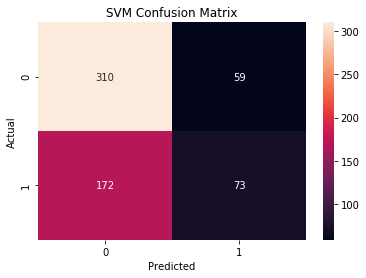

In [25]:
# SVM
svm = SVC(kernel='rbf')
svm.fit(X_train, Y_train)
svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(Y_test, svm_pred))
print(classification_report(Y_test, svm_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_test, svm_pred), annot=True, fmt="d")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

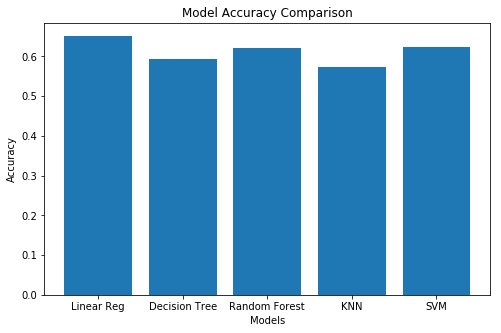

In [26]:
# MODEL COMPARISON
models = ["Linear Reg", "Decision Tree", "Random Forest", "KNN", "SVM"]
scores = [
    accuracy_score(Y_test, lr_pred_class),
    accuracy_score(Y_test, dt_pred),
    accuracy_score(Y_test, rf_pred),
    accuracy_score(Y_test, knn_pred),
    accuracy_score(Y_test, svm_pred)
]

plt.figure(figsize=(8,5))
plt.bar(models, scores)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()